# k-Nearest Neighbor (kNN) exercise 4a - FASHION-MNIST Dataset

*Complete and hand in this completed worksheet.*

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- In this exercise, the ultimate goal is to find an optimal value of hyper-parameter k through a cross-validation procedure.

In this exercise you will implement these steps and gain proficiency in writing efficient, vectorized code.

In [21]:
# Run some setup code for this notebook.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window. Also setting some parameters for display.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 10.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


In [22]:
# This is a method to read the MNIST dataset from a ROOT directory
def load_MNIST(ROOT):
  '''load all of mnist
  training set first'''
  Xtr = []
  train = pd.read_csv(os.path.join(ROOT, 'fashion-mnist_train.csv'))
  X = np.array(train.drop('label', axis=1))
  Ytr = np.array(train['label'])
  # With this for-loop we give the data a shape of the acctual image (28x28)
  # instead of the shape in file (1x784)
  for row in X:
      Xtr.append(row.reshape(28,28))
  # load test set second
  Xte = []
  test = pd.read_csv(os.path.join(ROOT, 'fashion-mnist_test.csv'))
  X = np.array(test.drop('label', axis=1))
  Yte = np.array(test['label'])
  # same reshaping
  for row in X:
      Xte.append(row.reshape(28,28))
  
  return np.array(Xtr), np.array(Ytr), np.array(Xte), np.array(Yte)


In [23]:
# Load the raw MNIST data.
mnist_dir = 'fashion-mnist'
X_train, y_train, X_test, y_test = load_MNIST(mnist_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (60000, 28, 28)
Training labels shape:  (60000,)
Test data shape:  (10000, 28, 28)
Test labels shape:  (10000,)


**Inline Question #1:** Notice the outputs of the shape attributes for the numpy arrays downloaded.

- What are the ranks of the arrays for the training data and test data? (1)
- Are the shapes coherent from the description of the dataset that we can find [here](http://yann.lecun.com/exdb/mnist/)? Explain the different dimensions of the 4 arrays in cell above. (2)

**Your Answer**:
1) The rank of an array is its nbr of dimensions. X_train and X_test have rank 3, while y_train and y_test have rank 1. When we use .shape, it gives the nbr of elements along each dimension. For example, X_train.shape = (60000,28, 28) contains 3 nbrs, so the array has a rank of 3. We can also check this directly with X_train.ndim:


In [24]:
X_train.ndim

3

2) The Fashion MNIST dataset contains a training set of 60'000 examples and a test set of 10'000 examples of Zalando article images. Each image is 28x28 pixels in grayscale, and each image is associated with a label from 10 classes (0 = T-shirt/top, 1 = Trouser, 2 = Pullover, 3 = Dress, 4 = Coat, 5 = Sandal, 6 = Shirt, 7 = Sneaker, 8 = Bag, 9 = Ankle boot). Fashion-MNIST was designed as a direct drop-in replacement for the original MNIST dataset: it shares the same image size, the same number of classes and the same train/test split. The shapes we obtained are coherent with this description.
- X_train (60000,28,28) = 60'000 training images, each with 28 rows x 28 columns of pxls
- y_train (60000,) = one label (0-9) for each training image
- X_test (10000,28,28) = 10'000 test images, each with 28 rows x 28 columns of pxls
- y_test (10000,) = one label (0-9) for each test image

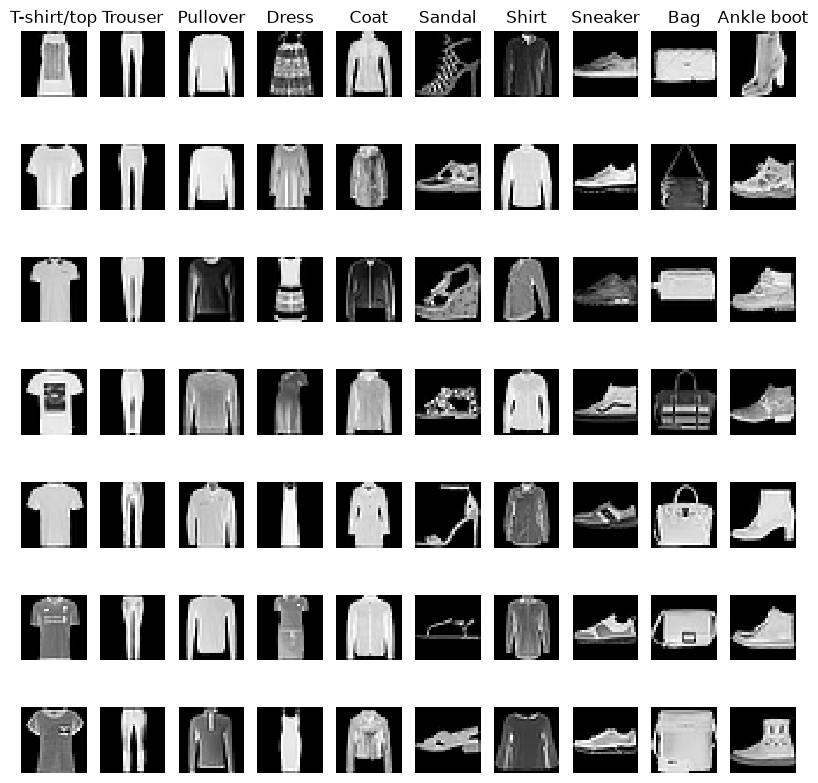

In [25]:
# Now let's visualise some of the images
classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal', 'Shirt','Sneaker', 'Bag', 'Ankle boot']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes): # y and cls takes values from 0-9
    idxs = np.flatnonzero(y_train == y) # gets the indices of samples that corresponds to class y
    idxs = np.random.choice(idxs, samples_per_class, replace=False) # picks randomly samples_per_class indices
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1   # determines the sub-plot index
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [26]:
# Subsample the data for more efficient code execution in this exercise. We do this to make it go faster. 
# When you will have completed the whole notebook, you can run it again on a larger (or total) dataset 
# and observe the difference in terms of accuracy (and speedup).
num_training = 5000
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (5000, 28, 28)
Training labels shape:  (5000,)
Test data shape:  (500, 28, 28)
Test labels shape:  (500,)


In [27]:
# Shape the images vectors
X_train = np.reshape(X_train, (X_train.shape[0], -1)) # when reshaping, -1 means "infer target dims from orig dims
X_test = np.reshape(X_test, (X_test.shape[0], -1))    # in this case it flattens the (28,28,3) into 3072 
print(X_train.shape, X_test.shape)

(5000, 784) (500, 784)


**Inline Question #2:** Notice the use of np.reshape to transform images into vectors.

- What is the effect of -1 in the reshape command? (1)
- Are the shapes coherent from this vectorization? Explain. (2)

**Your Answer**:
1) np.reshape changes the shape of an array without changing its data. So the total number of elements must stay the same. The "-1" tells Numpy to infer that dimension atuomatically from the total number of elements and the other given dimensions. Here with (x_train.shape[0],-1)=(5000,-1), the array has 5000x28x28=3'920'000 elements. So numpy computes 3'920'000/5'000 = 784. That mean each 28x28 image if therefor flattened into a  vector of 784 values.
2) YEs, X_train goes from (5000,28,28) to (5000,784) and X_test from (500,28,28) to (500,784). The number of image is unchanged and 28x28=784 so no pixel is lost or added. The arrays go from rank 3 to 2, where each row is one image as a vector.

In [28]:
# This is a class definition for our KNN classifier. Complete the code indicated by the TODO sections.
import numpy as np

class KNearestNeighbor(object):
  """ a kNN classifier with L2 distance """

  def __init__(self):
    pass

  def train(self, X, y):
    """
    Train the classifier. For k-nearest neighbors this is just 
    memorizing the training data.

    Inputs:
    - X: A numpy array of shape (num_train, D) containing the training data
      consisting of num_train samples each of dimension D.
    - y: A numpy array of shape (N,) containing the training labels, where
         y[i] is the label for X[i].
    """
    self.X_train = X
    self.y_train = y
    
  def predict(self, X, k=1, num_loops=0):
    """
    Predict labels for test data using this classifier.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data consisting
         of num_test samples each of dimension D.
    - k: The number of nearest neighbors that vote for the predicted labels.
    - num_loops: Determines which implementation to use to compute distances
      between training points and testing points.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted labels for the
      test data, where y[i] is the predicted label for the test point X[i].  
    """
    if num_loops == 0:
      dists = self.compute_distances_no_loops(X)
    elif num_loops == 1:
      dists = self.compute_distances_one_loop(X)
    elif num_loops == 2:
      dists = self.compute_distances_two_loops(X)
    else:
      raise ValueError('Invalid value %d for num_loops' % num_loops)

    return self.predict_labels(dists, k=k)

  def compute_distances_two_loops(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using a nested loop over both the training data and the 
    test data.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data.

    Returns:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      is the Euclidean distance between the ith test point and the jth training
      point.
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train))
    for i in range(num_test):
      for j in range(num_train):
        #####################################################################
        # TODO:                                                             #
        # Compute the l2 distance between the ith test point and the jth    #
        # training point, and store the result in dists[i, j]. You should   #
        # not use a loop over dimension.                                    #
        #####################################################################

        #L2 dist = square root of the sum of squared pxl differences (vectorized over the 784 dim)
        dists[i,j] = np.sqrt(np.sum((X[i]-self.X_train[j]) ** 2))
    
        #####################################################################
        #                       END OF YOUR CODE                            #
        #####################################################################
    return dists

  def compute_distances_one_loop(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using a single loop over the test data.

    Input / Output: Same as compute_distances_two_loops
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train))
    for i in range(num_test):
      #######################################################################
      # TODO:                                                               #
      # Compute the l2 distance between the ith test point and all training #
      # points, and store the result in dists[i, :].                        #
      #######################################################################

      #Use broadcastingsubtract X[i] from every training img, the sum over pxls
      dists[i,:] = np.sqrt(np.sum((self.X_train - X[i]) ** 2, axis=1))
    
      #######################################################################
      #                         END OF YOUR CODE                            #
      #######################################################################
    return dists

  def compute_distances_no_loops(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using no explicit loops.

    Input / Output: Same as compute_distances_two_loops
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train)) 
    #########################################################################
    # TODO:                                                                 #
    # Compute the l2 distance between all test points and all training      #
    # points without using any explicit loops, and store the result in      #
    # dists.                                                                #
    #                                                                       #
    # You should implement this function using only basic array operations; #
    # in particular you should not use functions from scipy.                #
    #                                                                       #
    # HINT: Try to formulate the l2 distance using matrix multiplication    #
    #       and two broadcast sums.                                         #
    #########################################################################

    #use ||x-y||^2 = ||x||^2  + ||y||^2 -2 x.y  (1 mtrx product + 2 broadcast sums

    # ||x||^2 for each test image, shape (num_test,1)
    test_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)

    # ||y||^2 for each train image, shape (1,num_train)
    train_sq = np.sum(self.X_train ** 2, axis=1).reshape(1,-1)

    # x.y for every pair, shape (num_test, num_train
    cross = np.dot(X, self.X_train.T)

    dists = np.sqrt(np.maximum(test_sq + train_sq - 2 * cross,0))



    #########################################################################
    #                         END OF YOUR CODE                              #
    #########################################################################
    return dists

  def predict_labels(self, dists, k=1):
    """
    Given a matrix of distances between test points and training points,
    predict a label for each test point.

    Inputs:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      gives the distance betwen the ith test point and the jth training point.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted labels for the
      test data, where y[i] is the predicted label for the test point X[i].  
    """
    num_test = dists.shape[0]
    y_pred = np.zeros(num_test)
    for i in range(num_test):
      # A list of length k storing the labels of the k nearest neighbors to
      # the ith test point.
      closest_y = []
      #########################################################################
      # TODO:                                                                 #
      # Use the distance matrix to find the k nearest neighbors of the ith    #
      # testing point, and use self.y_train to find the labels of these       #
      # neighbors. Store these labels in closest_y.                           #
      # Hint: Look up the function numpy.argsort.                             #
      #########################################################################

      #indics of the k training img with the smallest dist
      nearest_idx = np.argsort(dists[i])[:k]
      closest_y = self.y_train[nearest_idx]
      
      #########################################################################
      # TODO:                                                                 #
      # Now that you have found the labels of the k nearest neighbors, you    #
      # need to find the most common label in the list closest_y of labels.   #
      # Store this label in y_pred[i]. Break ties by choosing the smaller     #
      # label.                                                                #
      #########################################################################

      #count votes per label
      #argmax to return the smallest label in case of a tie
      y_pred[i] = np.argmax(np.bincount(closest_y))
      
      #########################################################################
      #                           END OF YOUR CODE                            # 
      #########################################################################

    return y_pred

In [29]:
# Create a kNN classifier instance. 
# Remember that training a kNN classifier is a noop: 
# the Classifier simply remembers the data and does no further processing 
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

In [30]:
# TODO: implement compute_distances_two_loops from the knn class definition above

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


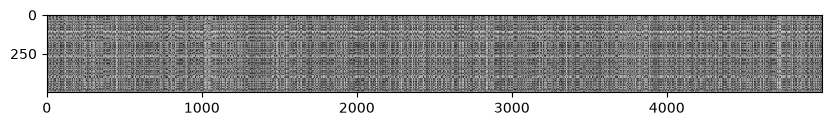

In [31]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question #3:** Notice the structured patterns in the distance matrix, where some rows or columns are visible brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows? (1)
- What causes the bright columns? (2)

**Your Answer**:
1) Each entry dists[i,j] is the L2 distance btw test image i (row) and training image j (column). White means a large distance. A bright row means that the test img is far from almost all training imgs. This happens when the test image contains many bright/non-zero pxls covering a large area of the image (e.g. pullovers, coats, shirts, bags), or when the article has an unusual/atypical appearance (very bright uniform surface, strong texture or pattern, unusual position in the image).
2) A bright column corresponds to a training image that is far from almost all test images. This happens for the same reason: the training article covers a large area with many bright pxls, or it has an unusual/atypical appearance compared to the rest of the dataset.

Conversely, darker rows and columns often correspond to thin or small articles such as sandals, sneakers or trousers. They have few non-zero pxls and are therefore close to many images in terms of L2 distance. This shows a limitation of the L2 distance on raw pxls: it mostly reflects the amount, brightness and position of the pxls rather than the actual shape or category of the clothing item. Two different articles with a similar surface and brightness (e.g. a pullover and a coat) can be very close, which also explains why kNN confuses these classes more often

In [32]:
# TODO : Now implement the function predict_labels from the KNN class above and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 392 / 500 correct => accuracy: 0.784000


You should expect to see approximately `90%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [33]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 407 / 500 correct => accuracy: 0.814000


You should expect to see a slightly better performance than with `k = 1`.

In [34]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('Difference was: %f' % (difference, ))
if difference < 0.001:
  print('Good! The distance matrices are the same')
else:
  print('Uh-oh! The distance matrices are different')

Difference was: 0.000000
Good! The distance matrices are the same


In [35]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('Difference was: %f' % (difference, ))
if difference < 0.001:
  print('Good! The distance matrices are the same')
else:
  print('Uh-oh! The distance matrices are different')

Difference was: 0.000000
Good! The distance matrices are the same


In [36]:
# Let's compare how fast the implementations are
def time_function(f, *args):
  """
  Call a function f with args and return the time (in seconds) that it took to execute.
  """
  import time
  tic = time.time()
  f(*args)
  toc = time.time()
  return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# you should see significantly faster performance with the fully vectorized implementation

Two loop version took 13.151397 seconds
One loop version took 14.824174 seconds
No loop version took 1.639799 seconds


### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [37]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50]

#X_train_folds = []
#y_train_folds = []
################################################################################
# TODO:                                                                        #
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.                                #
################################################################################
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


################################################################################
# TODO:                                                                        #
# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################
for k in k_choices:
    k_to_accuracies[k] = []
for fold in range(num_folds):
    #current fold is used as validation set
    X_val = X_train_folds[fold]
    y_val = y_train_folds[fold]

    #all other concatenated to form the training set
    X_tr = np.concatenate([X_train_folds[j] for j in range (num_folds) if j!=fold])
    y_tr = np.concatenate([y_train_folds[j] for j in range (num_folds) if j!=fold])

    classifier_cv = KNearestNeighbor()
    classifier_cv.train(X_tr, y_tr)
    dists_cv = classifier_cv.compute_distances_no_loops(X_val)

    for k in k_choices:
        y_val_pred = classifier_cv.predict_labels(dists_cv, k=k)
        accuracy = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(accuracy)


################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.810000
k = 1, accuracy = 0.792000
k = 1, accuracy = 0.804000
k = 1, accuracy = 0.810000
k = 1, accuracy = 0.789000
k = 3, accuracy = 0.809000
k = 3, accuracy = 0.792000
k = 3, accuracy = 0.810000
k = 3, accuracy = 0.813000
k = 3, accuracy = 0.794000
k = 5, accuracy = 0.806000
k = 5, accuracy = 0.797000
k = 5, accuracy = 0.811000
k = 5, accuracy = 0.821000
k = 5, accuracy = 0.798000
k = 8, accuracy = 0.802000
k = 8, accuracy = 0.794000
k = 8, accuracy = 0.816000
k = 8, accuracy = 0.805000
k = 8, accuracy = 0.801000
k = 10, accuracy = 0.803000
k = 10, accuracy = 0.800000
k = 10, accuracy = 0.808000
k = 10, accuracy = 0.807000
k = 10, accuracy = 0.800000
k = 12, accuracy = 0.805000
k = 12, accuracy = 0.798000
k = 12, accuracy = 0.809000
k = 12, accuracy = 0.809000
k = 12, accuracy = 0.799000
k = 15, accuracy = 0.797000
k = 15, accuracy = 0.782000
k = 15, accuracy = 0.804000
k = 15, accuracy = 0.795000
k = 15, accuracy = 0.781000
k = 20, accuracy = 0.800000
k = 20, accu

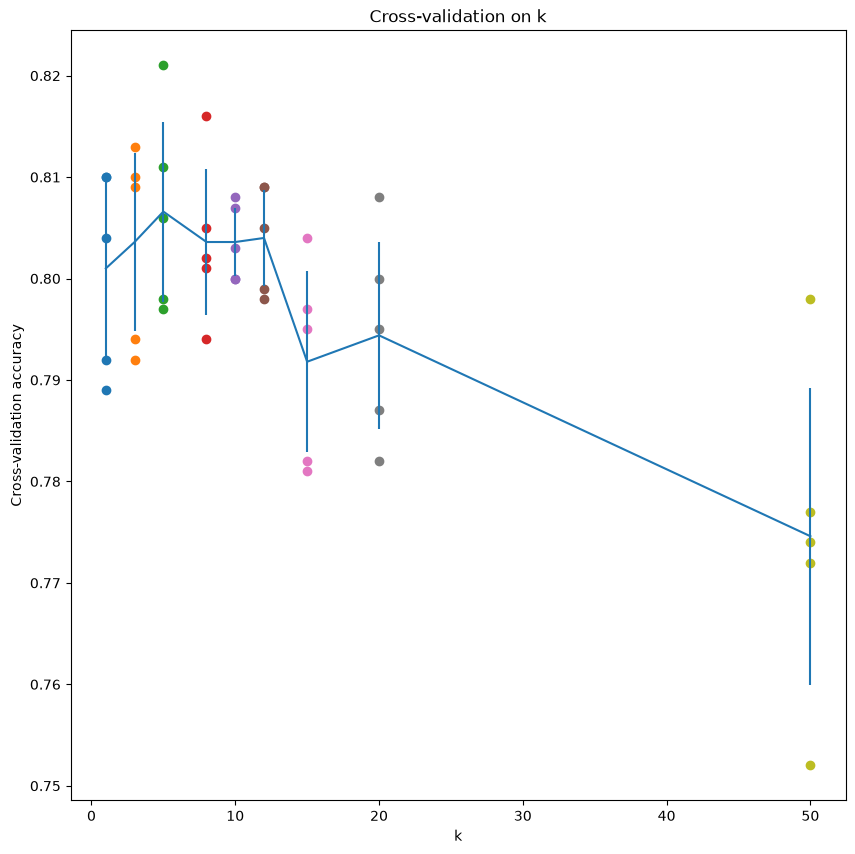

In [38]:
# plot the raw observations
for k in k_choices:
  accuracies = k_to_accuracies[k]
  plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [40]:
# Based on the cross-validation results above, choose the best value for k,   
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 90% accuracy on the test data.
best_k = 5   # TODO: put your best k value here
             # highest mean cross-validation accuracy (0.814)
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 407 / 500 correct => accuracy: 0.814000


## Compare Fashion MNIST dataset to the performances obtained on digit MNIST.

Both experiments were run with exactly the same setup: 5'000 training images, 500 test images, L2 distance on raw pxls, and 5-fold cross-validation over k {1, 3, 5, 8, 10, 12, 15, 20, 50}.

| | MNIST (digits) | Fashion-MNIST |
|---|---|---|
| Best k (cross-validation) | 1 | 5 |
| Mean CV accuracy (best k) | 92.9 % | 80.7 % |
| Test accuracy (best k) | 90.6 % | 81.4 % |
| Time, no-loop version | 1.31 s | 1.50 s |

**Accuracy:** kNN performs about 10-12 points worse on Fashion-MNIST than on MNIST, although both datasets have exactly the same format (28x28 grayscale images, 10 classes). Fashion-MNIST is therefore a harder classification problem for a pixel-based method. The main reason is that several clothing classes look very similar at the pxl level: T-shirt/top, Pullover, Coat and Shirt all have roughly the same shape and cover the same area of the image. The L2 distance on raw pxls cannot distinguish subtle details such as a collar, buttons or sleeve length, so these classes are often confused. In contrast, handwritten digits have more distinctive shapes, and a single nearest neighbor is usually enough to recognize them.

**Choice of k:** on MNIST the best value is k = 1 and accuracy decreases slowly as k increases. On Fashion-MNIST the best value is k = 5: letting several neighbors vote reduces the effect of individual confusing images, which helps when classes overlap. For both datasets, a very large k (k = 50) degrades the performance, because far away images from other classes start to influence the vote.

**Computation time:** the timings are almost identical, which is expected since both datasets have the same dimension (784 pxls per image) and we used the same number of training and test images. The cost of kNN depends only on the number of images and their dimension, not on the content of the images.

**Conclusion:** the pxl-based L2 distance works well when classes differ in their global shape (digits), but reaches its limits when classes differ in finer details (clothing). This motivates using better image representations (feature extraction), as proposed in part c).